In [45]:
import geopandas as gpd

import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from mpl_toolkits.axes_grid1 import make_axes_locatable

import pandas as pd

import time

In [4]:
indig = gpd.read_file("data/IPL_IndigenousPeoplesLands_2017/01_Data/IPL_IndigenousPeoplesLands_2017/IPL_2017.shp")


In [5]:
indig.shape

(88, 2)

In [6]:
indig_pro = indig.to_crs(epsg=4326)

In [7]:
indig_pro.columns

Index(['Name_', 'geometry'], dtype='object')

In [8]:
indig_in = indig_pro.set_index('Name_')

In [9]:
indig_in = indig_pro.explode()

C:\Users\admin\AppData\Local\Temp\ipykernel_5464\1514193147.py:1: FutureWarning: Currently, index_parts defaults to True, but in the future, it will default to False to be consistent with Pandas. Use `index_parts=True` to keep the current behavior and True/False to silence the warning.
  indig_in = indig_pro.explode()


In [10]:
indig_in.shape

(78504, 2)

In [11]:
def geo_plot(gdf, name, projection= ccrs.PlateCarree()):

    
        # Create a figure and axis with a specified projection
    fig, ax = plt.subplots(figsize=(20, 10), subplot_kw={'projection': ccrs.PlateCarree()})

    gdf.plot(ax=ax, transform = projection)

    # Add coastlines and land features
    ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
    ax.add_feature(cfeature.LAND, facecolor='lightgray')

    # Customize gridlines
    gl = ax.gridlines(draw_labels=True, linewidth=0.5, color='gray', alpha=0.5, linestyle='--')

    ax.set_axis_off()

    # Show the plot
    plt.tight_layout()  # Adjust layout to prevent overlap

    plt.savefig(f'fig/{name}'+'.png', dpi=300)
    plt.show()

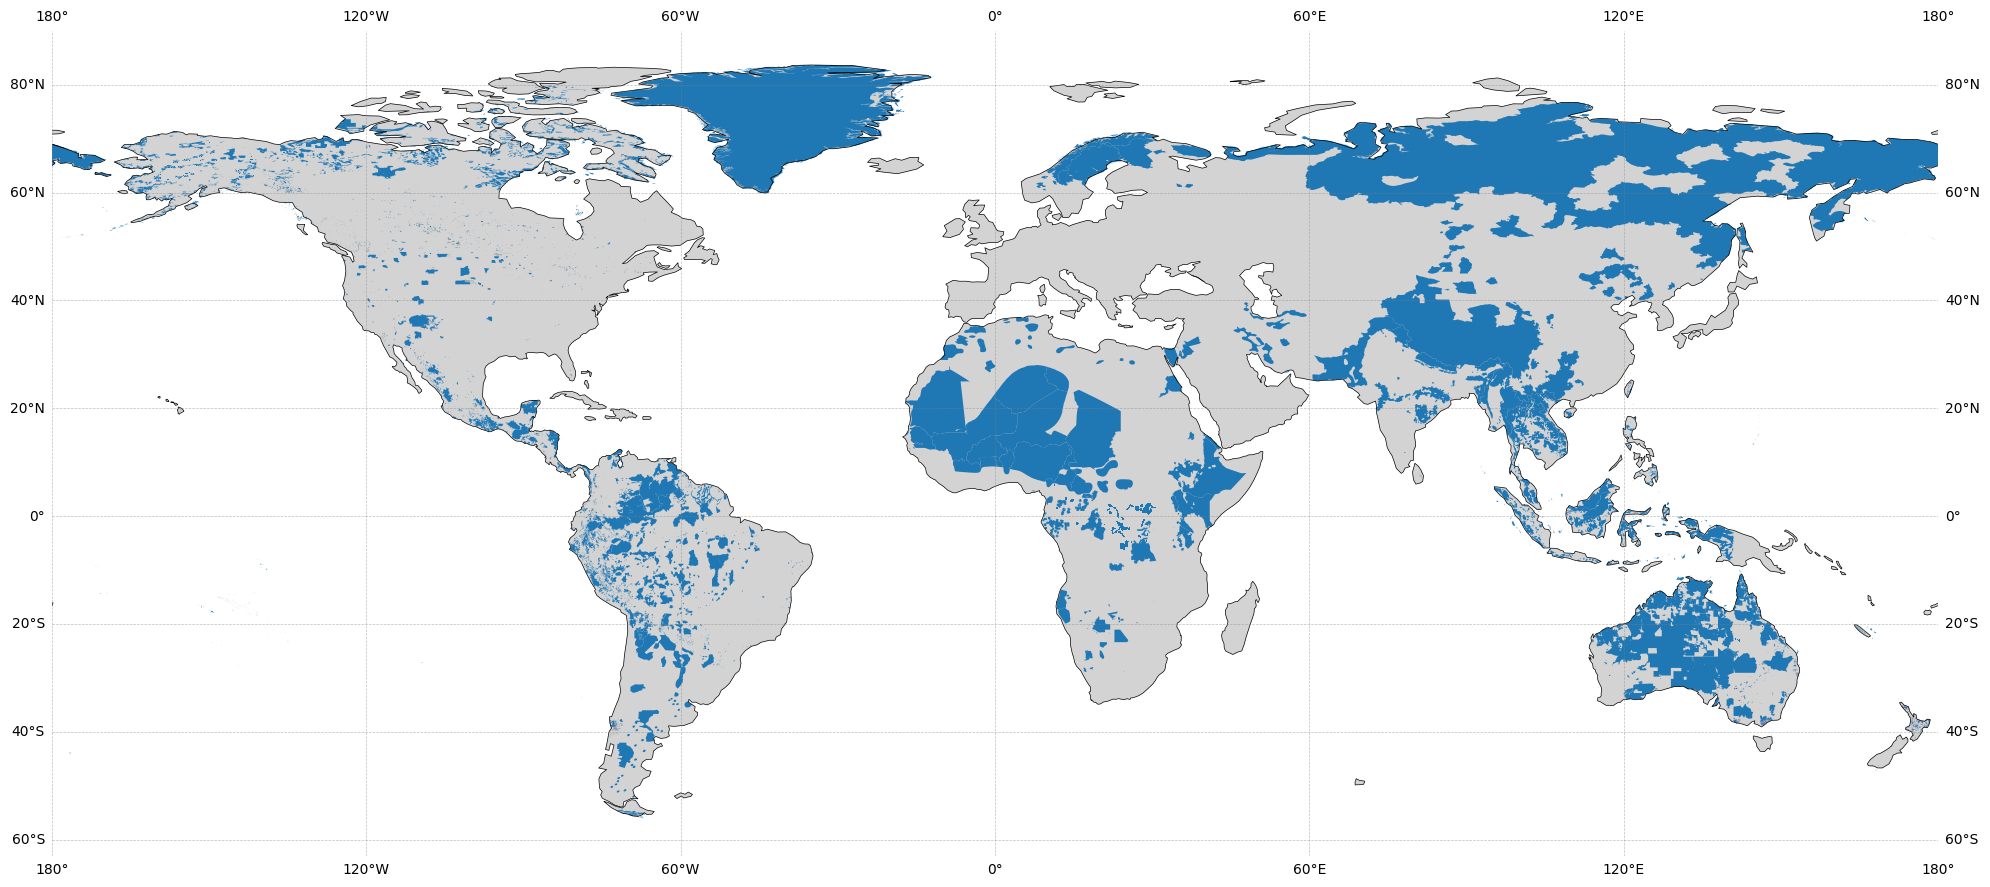

In [12]:

geo_plot(indig_pro, 'indigenous_land_areas')


In [13]:
indig_raster = gpd.read_file("data/IPL_IndigenousPeoplesLands_2017/01_Data/IPL_IndigenousPeoplesLands_100kmGrid_2017/IPL_2017_100kmGrid.shp")

In [14]:
indig_raster_pro = indig_raster.to_crs(epsg=4326)

In [15]:
indig_raster_pro.shape

(18440, 6)

In [16]:
indig_raster_pro.head(20)

,GRID_SQKM,IPL_SQKM,IPL_PC,gadm_SQKM,IPL_PCgadm,geometry
0,10000.0,0.0,0.0,210.720104,0,"POLYGON ((inf inf, inf inf, -174.74607 -86.968..."
1,10000.0,0.0,0.0,928.464945,0,"POLYGON ((inf inf, -174.74607 -86.96899, -168...."
2,10000.0,0.0,0.0,1610.343427,0,"POLYGON ((inf inf, -168.02667 -86.96899, -161...."
3,10000.0,0.0,0.0,2285.417163,0,"POLYGON ((inf inf, -161.30728 -86.96899, -154...."
4,10000.0,0.0,0.0,2941.165628,0,"POLYGON ((inf inf, -154.58789 -86.96899, -147...."
5,10000.0,0.0,0.0,3535.080573,0,"POLYGON ((inf inf, -147.86849 -86.96899, -141...."
6,10000.0,0.0,0.0,4124.357343,0,"POLYGON ((inf inf, -141.14910 -86.96899, -134...."
7,10000.0,0.0,0.0,4699.955429,0,"POLYGON ((inf inf, -134.42970 -86.96899, -127...."
8,10000.0,0.0,0.0,5206.640662,0,"POLYGON ((inf inf, -127.71031 -86.96899, -120...."
9,10000.0,0.0,0.0,5703.785754,0,"POLYGON ((inf inf, -120.99091 -86.96899, -114...."


In [17]:
mines = gpd.read_file("data\mine-comm\global_mining_land_use_comm.gpkg")

In [18]:
mines.columns

Index(['area', 'admin', 'adm0_a3', 'row.id', 'list_of_commodities',
       'geometry'],
      dtype='object')

In [19]:
minesid = mines.set_index('row.id')

In [20]:
minesid

,area,admin,adm0_a3,list_of_commodities,geometry
row.id,,,,,
1,0.038096,New Zealand,NZL,"Ilmenite,Rutile,Zircon,Heavy Mineral Sands,Gol...","MULTIPOLYGON (((171.46400 -42.43900, 171.46250..."
2,0.114247,New Zealand,NZL,"Ilmenite,Rutile,Zircon,Heavy Mineral Sands,Gol...","MULTIPOLYGON (((171.28440 -42.43580, 171.28290..."
3,0.125528,New Zealand,NZL,"Molybdenum,Tin,Silver,Gold","MULTIPOLYGON (((170.87480 -42.85890, 170.87220..."
4,0.288590,New Zealand,NZL,Coal,"MULTIPOLYGON (((168.00960 -45.95730, 168.00900..."
5,0.349819,New Zealand,NZL,Coal,"MULTIPOLYGON (((167.88650 -45.89680, 167.88620..."
...,...,...,...,...,...
81558,0.055417,China,CHN,None,"MULTIPOLYGON (((110.92507 41.11132, 110.92504 ..."
81559,0.034229,China,CHN,None,"MULTIPOLYGON (((110.91125 41.10848, 110.91125 ..."
81560,0.031565,China,CHN,None,"MULTIPOLYGON (((110.91224 41.10593, 110.91222 ..."


In [36]:
minesid.head()

,area,admin,adm0_a3,list_of_commodities,geometry
row.id,,,,,
1,0.038096,New Zealand,NZL,"Ilmenite,Rutile,Zircon,Heavy Mineral Sands,Gol...","MULTIPOLYGON (((171.46400 -42.43900, 171.46250..."
2,0.114247,New Zealand,NZL,"Ilmenite,Rutile,Zircon,Heavy Mineral Sands,Gol...","MULTIPOLYGON (((171.28440 -42.43580, 171.28290..."
3,0.125528,New Zealand,NZL,"Molybdenum,Tin,Silver,Gold","MULTIPOLYGON (((170.87480 -42.85890, 170.87220..."
4,0.288590,New Zealand,NZL,Coal,"MULTIPOLYGON (((168.00960 -45.95730, 168.00900..."
5,0.349819,New Zealand,NZL,Coal,"MULTIPOLYGON (((167.88650 -45.89680, 167.88620..."


In [22]:
indig_pro.head()

,Name_,geometry
0,ARG,"MULTIPOLYGON Z (((-68.90305 -51.71368 0.00000,..."
1,ASM,MULTIPOLYGON Z (((-168.14500 -14.54528 0.00000...
2,AUS,"MULTIPOLYGON Z (((147.36668 -43.17054 0.00000,..."
3,BDI,"MULTIPOLYGON Z (((29.33815 -3.65799 0.00000, 2..."
4,BEN,"POLYGON Z ((2.89049 12.36722 0.00000, 2.90662 ..."


In [23]:
indig_ex = indig_pro.explode()

C:\Users\admin\AppData\Local\Temp\ipykernel_5464\3838390920.py:1: FutureWarning: Currently, index_parts defaults to True, but in the future, it will default to False to be consistent with Pandas. Use `index_parts=True` to keep the current behavior and True/False to silence the warning.
  indig_ex = indig_pro.explode()


In [24]:
indig_ex.shape

(78504, 2)

In [25]:
indig_ex.reset_index(inplace=True)

In [26]:
indig_ex.head()

,level_0,level_1,Name_,geometry
0,0,0,ARG,"POLYGON Z ((-68.90305 -51.71368 0.00000, -68.9..."
1,0,1,ARG,"POLYGON Z ((-71.93108 -51.17015 0.00000, -72.0..."
2,0,2,ARG,"POLYGON Z ((-70.61048 -50.96789 0.00000, -70.7..."
3,0,3,ARG,"POLYGON Z ((-73.12081 -50.32544 0.00000, -73.2..."
4,0,4,ARG,"POLYGON Z ((-72.24041 -49.82575 0.00000, -72.4..."


In [27]:
indig_ex.drop(columns=['level_0', 'level_1'], inplace=True)

In [28]:
indig_ex.set_index('Name_', inplace=True)

# Footprinting

In [29]:
minesid.head()

,area,admin,adm0_a3,list_of_commodities,geometry
row.id,,,,,
1,0.038096,New Zealand,NZL,"Ilmenite,Rutile,Zircon,Heavy Mineral Sands,Gol...","MULTIPOLYGON (((171.46400 -42.43900, 171.46250..."
2,0.114247,New Zealand,NZL,"Ilmenite,Rutile,Zircon,Heavy Mineral Sands,Gol...","MULTIPOLYGON (((171.28440 -42.43580, 171.28290..."
3,0.125528,New Zealand,NZL,"Molybdenum,Tin,Silver,Gold","MULTIPOLYGON (((170.87480 -42.85890, 170.87220..."
4,0.288590,New Zealand,NZL,Coal,"MULTIPOLYGON (((168.00960 -45.95730, 168.00900..."
5,0.349819,New Zealand,NZL,Coal,"MULTIPOLYGON (((167.88650 -45.89680, 167.88620..."


In [69]:

def calc_inter(mland, iland, buffer_list=[0, 10, 30, 50]):
    mland_pro = mland.to_crs(epsg=3857)
    mland_pro['ID'] = mland_pro.index

    iland_pro = iland.to_crs(epsg=3857)

    over_dis_collect = []

    for i, buffer in enumerate(buffer_list):
        start_time = time.time()  # Start the timer
        
        mland_buffered = mland_pro.copy()
        mland_buffered['geometry'] = mland_pro.buffer(buffer*10**3)
        over = gpd.overlay(mland_buffered, iland_pro, how='intersection') 
        
        over_dis = over.dissolve(by='ID')

        over_dis['area_km2'] = over_dis.area * 10**(-6)

        over_dis['buffer'] = buffer

        over_dis_collect.append(over_dis)

        elapsed_time = time.time() - start_time  # Calculate elapsed time
        print(f'Buffer: {buffer}km, Number of mines: {over_dis.shape}, Elapsed Time: {elapsed_time/60:.2f} min, Buffers left: {len(buffer_list)-i}'
        )

    over_df = pd.concat(over_dis_collect, axis=0)

    return over_df


join_direct = calc_inter(mland=minesid, iland = indig_ex, buffer_list=[0, 10, 30, 50])

Buffer: 0km, Number of mines: (10908, 7), Elapsed Time: 11.72 min, Buffers left: 4
Buffer: 10km, Number of mines: (16198, 7), Elapsed Time: 40.34 min, Buffers left: 3
Buffer: 30km, Number of mines: (22863, 7), Elapsed Time: 72.43 min, Buffers left: 2
Buffer: 50km, Number of mines: (27573, 7), Elapsed Time: 113.59 min, Buffers left: 1


In [71]:
join_direct.shape

(77542, 7)

In [72]:
join_direct.to_file('data/interm/mine_indig_footprint.gpkg', driver='GPKG')

In [38]:
join_direct.index

RangeIndex(start=0, stop=11125, step=1)

In [32]:
join_meter = join_direct.to_crs('3857')

In [33]:
join_direct['direct_fp'] = join_meter.area

In [34]:
join_direct.head(20)

,area,admin,adm0_a3,list_of_commodities,geometry,direct_fp
0,0.040195,Australia,AUS,Coal,"POLYGON Z ((152.65790 -27.64850 0.00000, 152.6...",5.134195e+04
1,0.372366,Australia,AUS,"Copper,U3O8,Gold,Zinc,Lead,Silver,Platinum,Nic...","POLYGON Z ((141.41076 -31.97166 0.00000, 141.4...",1.775658e+02
2,0.372366,Australia,AUS,"Copper,U3O8,Gold,Zinc,Lead,Silver,Platinum,Nic...","POLYGON Z ((141.41310 -31.96490 0.00000, 141.4...",9.047478e+04
3,0.048309,Australia,AUS,"U3O8,Copper,Molybdenum,Lithium,Tungsten,Niobiu...","POLYGON Z ((139.57480 -30.18390 0.00000, 139.5...",6.479757e+04
4,0.242487,Australia,AUS,"U3O8,Copper,Molybdenum,Lithium,Tungsten,Niobiu...","POLYGON Z ((139.55710 -30.18340 0.00000, 139.5...",3.252915e+05
5,0.172674,Australia,AUS,"U3O8,Copper,Molybdenum,Lithium,Tungsten,Niobiu...","POLYGON Z ((139.55610 -30.11510 0.00000, 139.5...",2.312925e+05
6,0.058386,Australia,AUS,None,"POLYGON Z ((135.33080 -29.67560 0.00000, 135.3...",7.751827e+04
7,0.088466,Australia,AUS,"Ilmenite,Rutile,Zircon,Heavy Mineral Sands","POLYGON Z ((132.12130 -30.91590 0.00000, 132.1...",1.204671e+05
8,18.898402,Australia,AUS,"Gold,Nickel,Copper,Cobalt,Platinum,Chromite,Pa...","POLYGON Z ((123.15660 -31.81380 0.00000, 123.1...",2.623262e+07
9,0.461226,Australia,AUS,"Gold,Nickel,Copper,Silver,Lithium,Cobalt,Zinc,...","POLYGON Z ((121.78570 -32.38760 0.00000, 121.7...",6.484015e+05


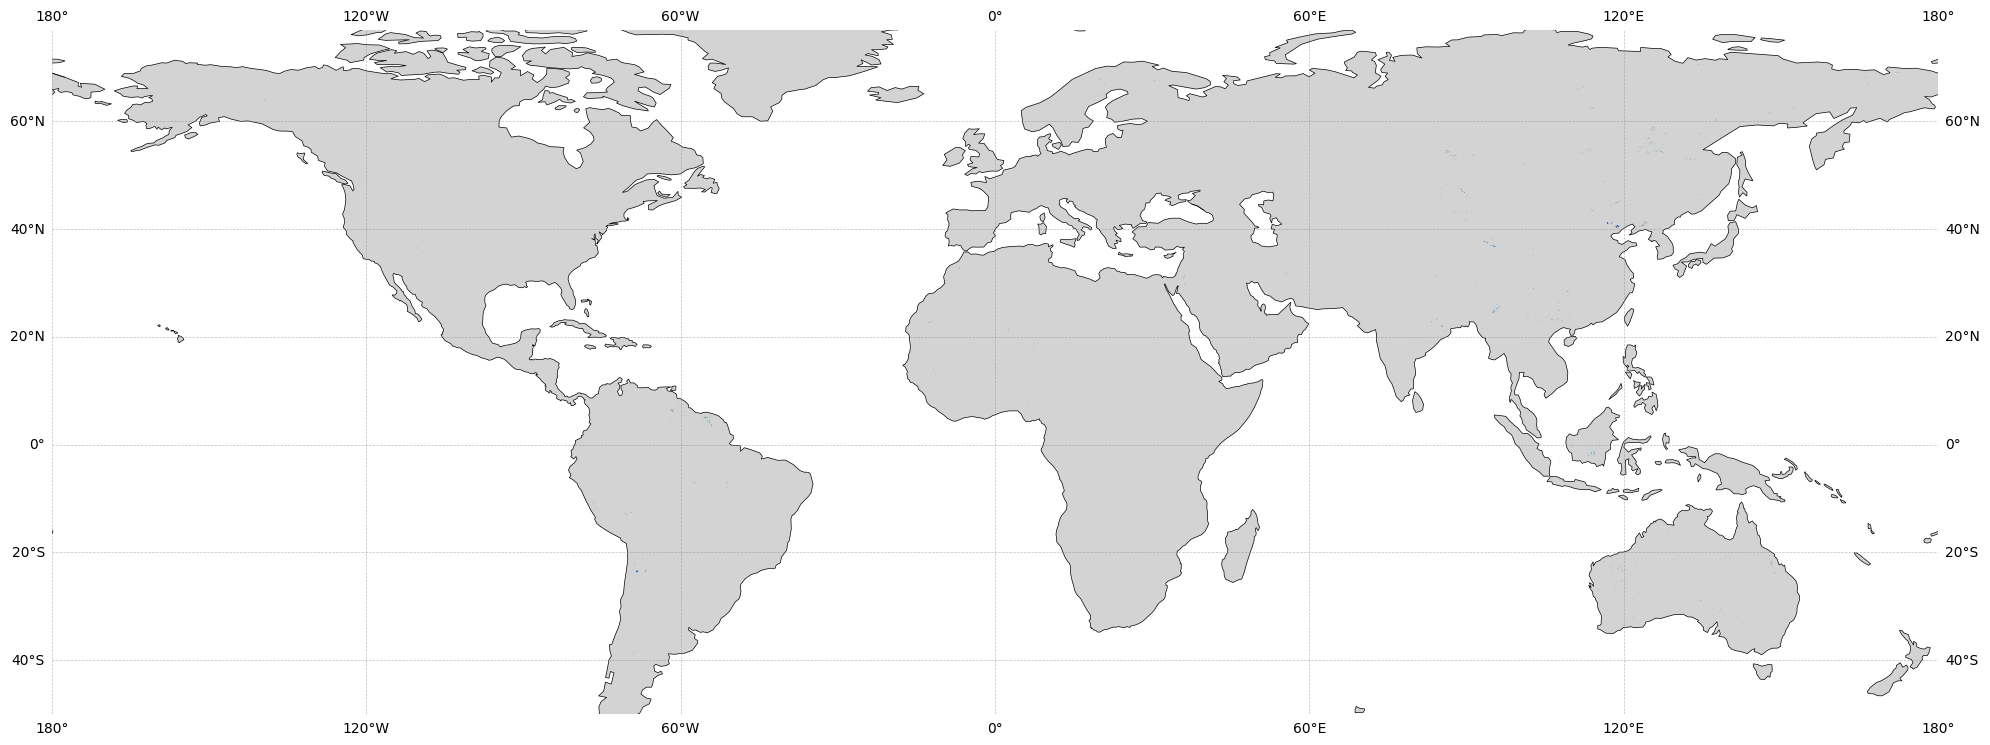

In [35]:
geo_plot(join_direct, 'Direct land use footprint')